Batch accuracy : 0.80494
Mini-batch accuracy : 0.80586
Linear regression MSE : 0.14210903527230934
Batch final loss : 0.4250968987613871
Mini-batch final loss : 0.41522900251459904


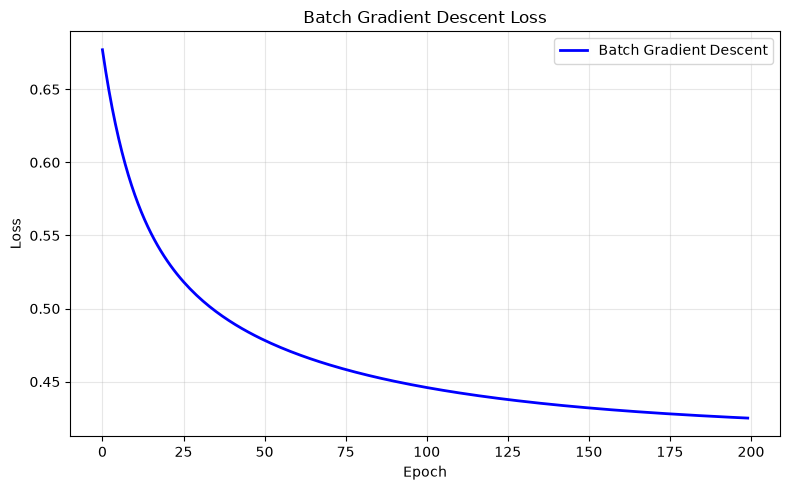

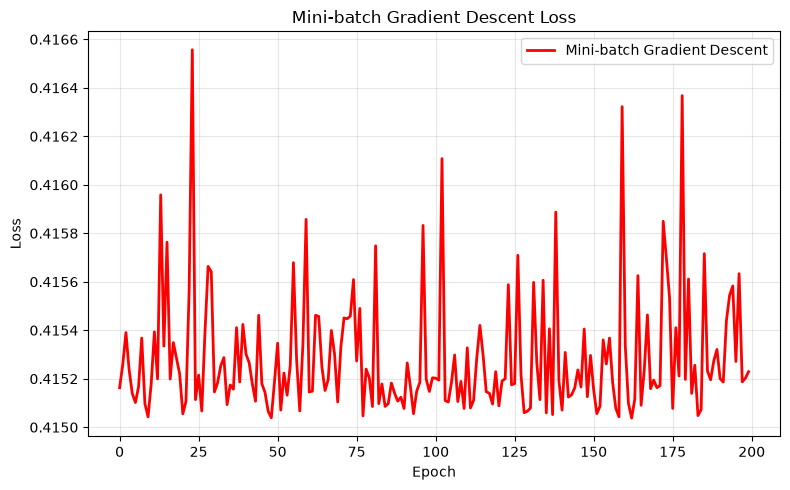

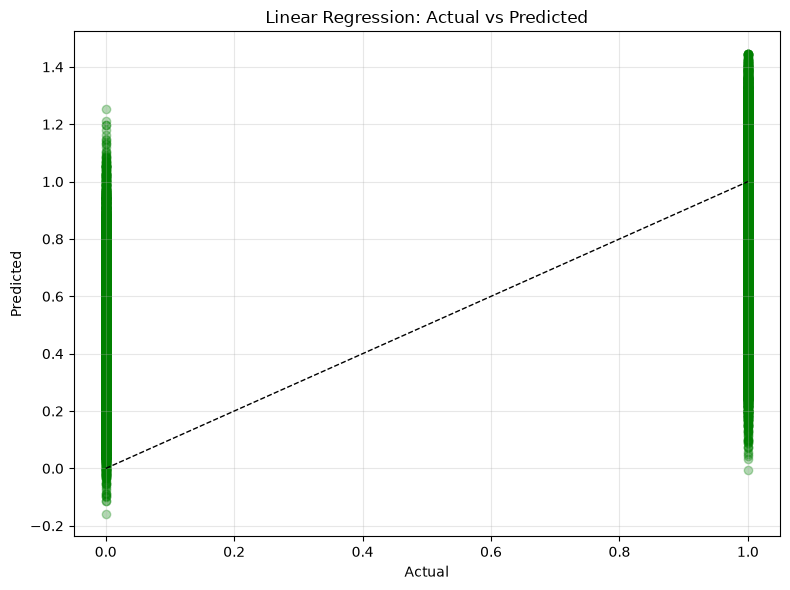

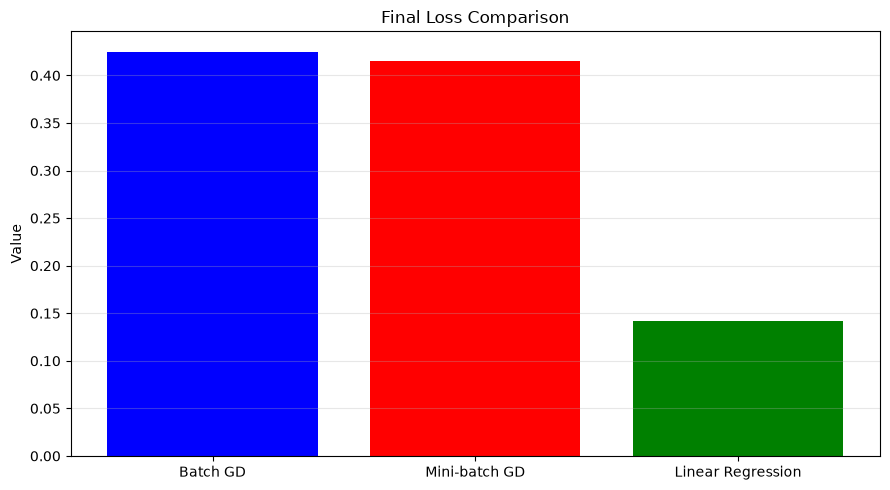

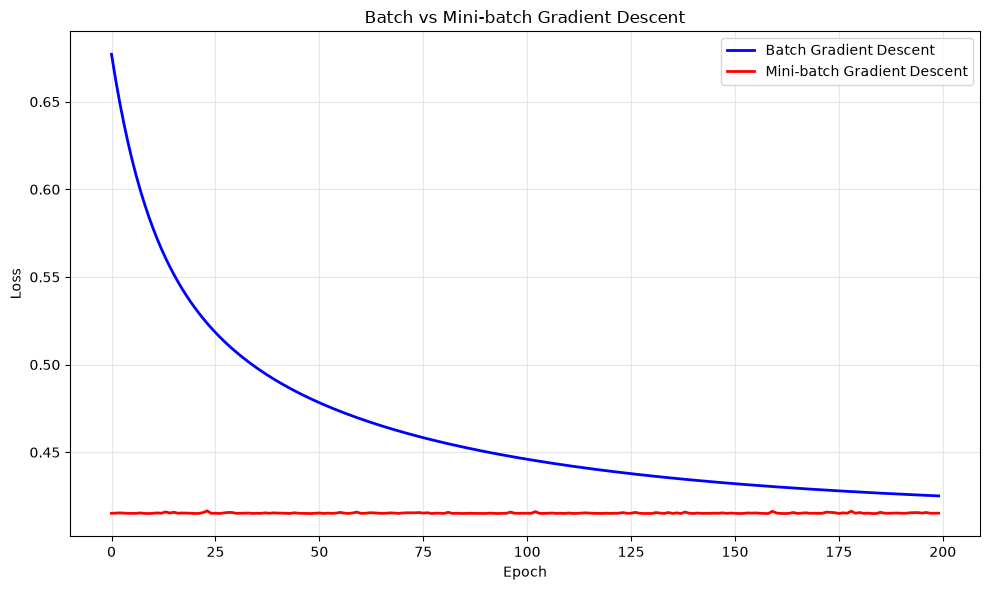

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv("placement_predict_50k.csv")

# Convert categorical fields
df["PlacementTraining"] = (df["PlacementTraining"] == "Yes").astype(float)

features = [
    "CGPA", "Internships", "Projects", "AptitudeScore",
    "SoftSkillsRating", "Backlogs", "PlacementTraining"
]

X = df[features].to_numpy(dtype=float)
y = (df["PlacementStatus"] == "Placed").astype(float).to_numpy(dtype=float)

# Standardize features
mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1
X = (X - mean) / std

# ---------- Helper functions ----------
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def compute_loss(X, y, w, b):
    z = X @ w + b
    p = sigmoid(z)
    eps = 1e-8
    return -(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)).mean()


def accuracy(X, y, w, b):
    p = sigmoid(X @ w + b)
    pred = (p >= 0.5).astype(float)
    return np.mean(pred == y)


# ---------- Batch gradient descent ----------
def batch_gradient_descent(X, y, lr=0.05, epochs=200):
    n, m = X.shape
    w = np.zeros(m)
    b = 0.0
    losses = []
    for _ in range(epochs):
        p = sigmoid(X @ w + b)
        dw = (1 / n) * (X.T @ (p - y))
        db = (1 / n) * np.sum(p - y)
        w -= lr * dw
        b -= lr * db
        losses.append(compute_loss(X, y, w, b))
    return w, b, losses


# ---------- Mini-batch gradient descent ----------
def mini_batch_gradient_descent(X, y, lr=0.05, epochs=200, batch_size=32):
    n, m = X.shape
    w = np.zeros(m)
    b = 0.0
    losses = []
    for _ in range(epochs):
        idx = np.random.permutation(n)
        Xs = X[idx]
        ys = y[idx]
        for start in range(0, n, batch_size):
            end = start + batch_size
            Xb = Xs[start:end]
            yb = ys[start:end]
            p = sigmoid(Xb @ w + b)
            dw = (1 / len(Xb)) * (Xb.T @ (p - yb))
            db = (1 / len(Xb)) * np.sum(p - yb)
            w -= lr * dw
            b -= lr * db
        losses.append(compute_loss(X, y, w, b))
    return w, b, losses


# ---------- Train all models ----------
w_batch, b_batch, loss_batch = batch_gradient_descent(X, y, lr=0.05, epochs=200)
w_mini, b_mini, loss_mini = mini_batch_gradient_descent(X, y, lr=0.05, epochs=200, batch_size=32)

# Linear regression baseline (Direct comparison)
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
linear_mse = mean_squared_error(y, y_pred_linear)

print('Batch accuracy :', accuracy(X, y, w_batch, b_batch))
print('Mini-batch accuracy :', accuracy(X, y, w_mini, b_mini))
print('Linear regression MSE :', linear_mse)
print('Batch final loss :', loss_batch[-1])
print('Mini-batch final loss :', loss_mini[-1])

# ---------- Separate plots ----------
plt.figure(figsize=(8, 5))
plt.plot(loss_batch, label='Batch Gradient Descent', color='blue', linewidth=2)
plt.title('Batch Gradient Descent Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(loss_mini, label='Mini-batch Gradient Descent', color='red', linewidth=2)
plt.title('Mini-batch Gradient Descent Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_linear, alpha=0.3, color='green')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Comparison plot ----------
final_losses = {
    'Batch GD': loss_batch[-1],
    'Mini-batch GD': loss_mini[-1],
    'Linear Regression': linear_mse
}

plt.figure(figsize=(9, 5))
plt.bar(final_losses.keys(), final_losses.values(), color=['blue', 'red', 'green'])
plt.title('Final Loss Comparison')
plt.ylabel('Value')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Optional combined loss comparison curve for batch and mini-batch only
plt.figure(figsize=(10, 6))
plt.plot(loss_batch, label='Batch Gradient Descent', color='blue', linewidth=2)
plt.plot(loss_mini, label='Mini-batch Gradient Descent', color='red', linewidth=2)
plt.title('Batch vs Mini-batch Gradient Descent')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()